<a href="https://colab.research.google.com/github/likithams09/Generative-AI-Lab/blob/main/3_GAN_Scenarios.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

You are an AI engineer working for an online fashion company. Build a GAN that learns from existing clothing images and generates new fashion
designs.
Fashion MNIST Dataset

In [ ]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
device = "cuda" if torch.cuda.is_available() else "cpu"

Data Acquisition

In [ ]:
data = torchvision.datasets.FashionMNIST(
    root="./data", train=True, download=True,
    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,),(0.5,))
    ])
)
loader = torch.utils.data.DataLoader(data,128, shuffle=True)

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.8MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 203kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.76MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 26.1MB/s]


define generator network

In [3]:
G = nn.Sequential(
    nn.Linear(100,256), nn.ReLU(),
    nn.Linear(256,512), nn.ReLU(),
    nn.Linear(512,784),nn.Tanh()
).to(device)

Define Discriminator Network

In [4]:
D = nn.Sequential(
    nn.Linear(784,512),nn.LeakyReLU(0.2),
    nn.Linear(512,256),nn.LeakyReLU(0.2),
    nn.Linear(256,1), nn.Sigmoid()
).to(device)

Loss Calculation

In [5]:
loss = nn.BCELoss()
g_opt = torch.optim.Adam(G.parameters(), lr=0.0002)
d_opt = torch.optim.Adam(D.parameters(), lr=0.0002)

Train the GAN

In [7]:
# Training
epochs = 20
for epoch in range(epochs):
    for real_images, _ in loader:

        # Prepare real images
        real_images = real_images.view(-1, 784).to(device)
        batch_size = real_images.size(0)

        # Labels
        real_labels = torch.ones(batch_size, 1).to(device)
        fake_labels = torch.zeros(batch_size, 1).to(device)

        # Train Discriminator

        # Real images
        real_output = D(real_images)
        d_real_loss = loss(real_output, real_labels)

        # Generate fake images
        noise = torch.randn(batch_size, 100).to(device)
        fake_images = G(noise)

        # Fake images
        fake_output = D(fake_images.detach())
        d_fake_loss = loss(fake_output, fake_labels)

        # Total discriminator loss
        d_loss = d_real_loss + d_fake_loss

        d_opt.zero_grad()
        d_loss.backward()
        d_opt.step()

        # Train Generator

        noise = torch.randn(batch_size, 100).to(device)
        fake_images = G(noise)

        fake_output = D(fake_images)

        # Generator wants discriminator to classify fake as real
        g_loss = loss(fake_output, real_labels)

        g_opt.zero_grad()
        g_loss.backward()
        g_opt.step()

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"D Loss: {d_loss.item():.4f} "
        f"G Loss: {g_loss.item():.4f}"
    )

Epoch [1/20] D Loss: 0.0244 G Loss: 7.2200
Epoch [2/20] D Loss: 0.1211 G Loss: 6.1582
Epoch [3/20] D Loss: 0.3570 G Loss: 5.5331
Epoch [4/20] D Loss: 0.1422 G Loss: 5.1088
Epoch [5/20] D Loss: 0.3452 G Loss: 4.7353
Epoch [6/20] D Loss: 0.1934 G Loss: 4.7532
Epoch [7/20] D Loss: 0.1119 G Loss: 5.7669
Epoch [8/20] D Loss: 0.1552 G Loss: 5.5205
Epoch [9/20] D Loss: 0.2793 G Loss: 4.9860
Epoch [10/20] D Loss: 0.3748 G Loss: 5.5741
Epoch [11/20] D Loss: 0.2181 G Loss: 5.5110
Epoch [12/20] D Loss: 0.1621 G Loss: 4.2726
Epoch [13/20] D Loss: 0.2600 G Loss: 4.9748
Epoch [14/20] D Loss: 0.2725 G Loss: 3.9345
Epoch [15/20] D Loss: 0.5465 G Loss: 3.2698
Epoch [16/20] D Loss: 0.1896 G Loss: 4.8150
Epoch [17/20] D Loss: 0.2751 G Loss: 3.3763
Epoch [18/20] D Loss: 0.5756 G Loss: 4.7402
Epoch [19/20] D Loss: 0.3547 G Loss: 4.1805
Epoch [20/20] D Loss: 0.4450 G Loss: 3.2507


Generate New Fashion Designs

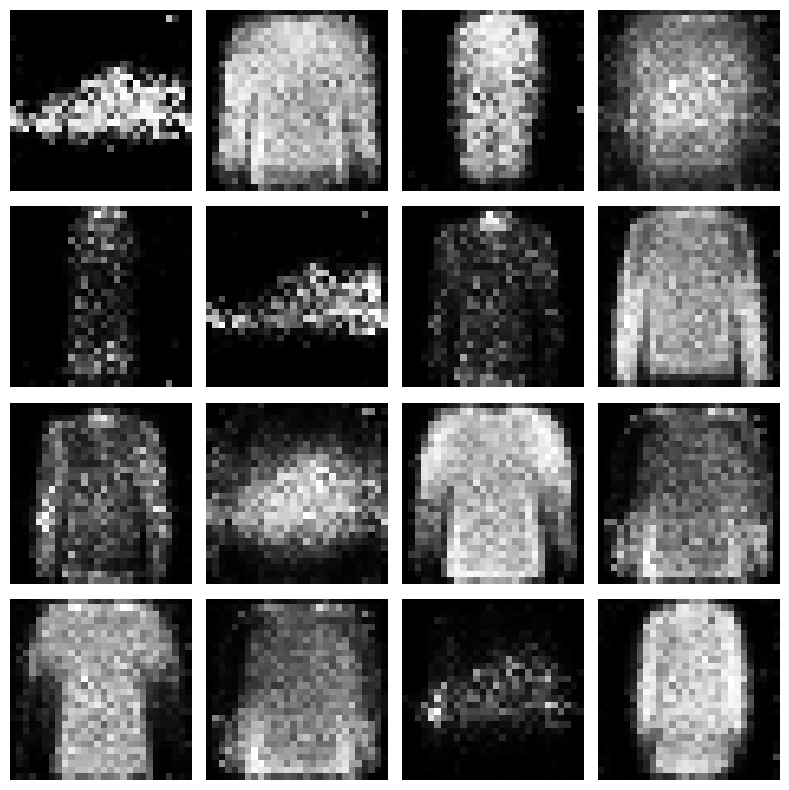

In [8]:
# Generate new images
G.eval()
with torch.no_grad():
    noise = torch.randn(16, 100).to(device)
    generated_images = G(noise)
generated_images = generated_images.view(-1, 28, 28)

# Display generated images
plt.figure(figsize=(8, 8))

for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(generated_images[i].cpu(), cmap="gray")
    plt.axis("off")

plt.tight_layout()
plt.show()